In [1]:
import warnings
warnings.filterwarnings('ignore')
!pip install numpy
!pip install -U "cupy-cuda13x[ctk]"
!pip install types-array-api
!pip install array-api-compat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.5/410.5 MB 4.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.1/51.1 MB 17.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.7/184.7 MB 6.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 MB 20.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.7/244.7 MB 4.6 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 MB 7.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.5/69.5 MB 11.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 MB 21.7 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-toolkit
    Found existing installation: cuda-toolkit 12.8.1
    Uninstalling cuda-toolkit-12.8.1:
      Successfully uninstalled cuda-toolkit-12.8.1
ERROR: pip's depende

In [3]:
!git clone https://github.com/Ankit-539/QuanSToS.git

Cloning into 'QuanSToS'...
remote: Enumerating objects: 147, done.
remote: Counting objects: 100% (147/147), done.
remote: Compressing objects: 100% (110/110), done.
Receiving objects: 100% (147/147), 218.11 KiB | 5.07 MiB/s, done.
remote: Total 147 (delta 90), reused 76 (delta 35), pack-reused 0 (from 0)
Resolving deltas: 100% (90/90), done.


In [4]:
%cd QuanSToS

/content/QuanSToS


In [5]:
from time import perf_counter

# import cupy as cp
import numpy as np
import array_api_compat
import array_api_compat.cupy as cp
import math
import matplotlib.pyplot as plt

from src import (
    get_random_haar,
    get_random_mixed,
    get_random_product,
    get_random_product_pole_biased,
    inverse_estimator,
    mle,
    fidelity,
    negativity,
    pauli_measurement,
    plot_counts,
    bloch_vector
)

# Virtual Pauli measurements

XXX  [12412 12371 12590 12424 12494 12515 12600 12594]
XXY  [12489 12592 12580 12366 12571 12501 12354 12547]
XXZ  [21214  3639 21267  3842 21308  3803 21112  3815]
XYX  [12474 12458 12399 12575 12604 12635 12364 12491]
XYY  [12646 12484 12336 12434 12641 12534 12521 12404]
XYZ  [21128  3704 21391  3715 21244  3777 21291  3750]
XZX  [21182 21197  3807  3737 21294 21256  3827  3700]
XZY  [21233 21317  3756  3838 21167 21172  3792  3725]
XZZ  [38663  3711  3722  3806 38787  3759  3798  3754]
YXX  [12511 12619 12332 12370 12466 12492 12698 12512]
YXY  [12588 12450 12481 12393 12324 12720 12787 12257]
YXZ  [21422  3720 21242  3751 21134  3646 21285  3800]
YYX  [12543 12490 12696 12462 12465 12538 12469 12337]
YYY  [12523 12508 12437 12474 12369 12474 12658 12557]
YYZ  [21204  3759 21195  3816 21095  3759 21318  3854]
YZX  [21308 21272  3749  3735 21252 21289  3731  3664]
YZY  [21206 21226  3821  3642 21211 21345  3748  3801]
YZZ  [38377  3813  3816  3810 38761  3899  3734  3790]
ZXX  [2119

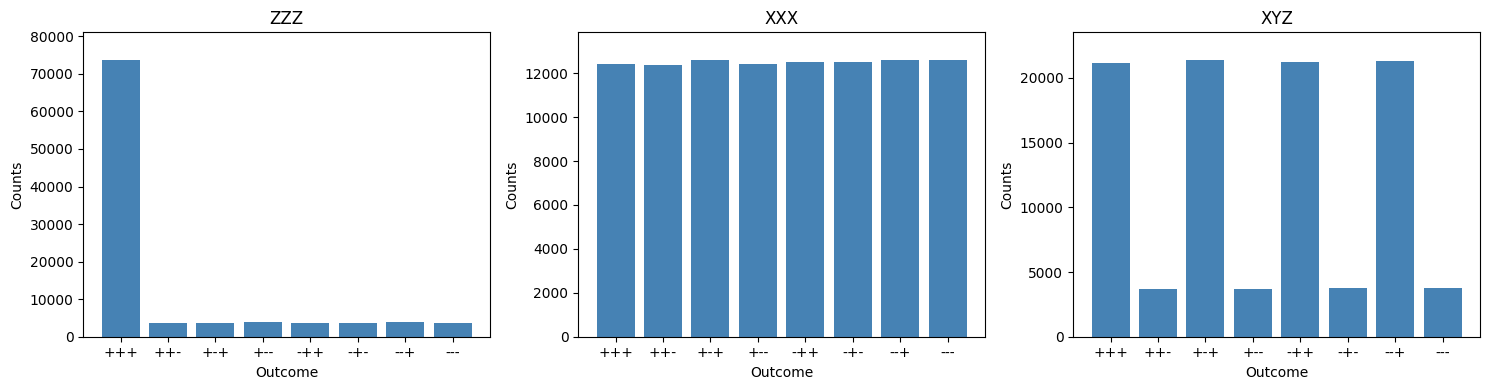

In [6]:
p = 0.7
rho_000 = np.zeros((8, 8), dtype=np.complex128)
rho_000[0, 0] = 1
rho_partial = (p*rho_000 + (1-p)*np.eye(8, dtype=np.complex128)/8)

N = 100_000

result = pauli_measurement(rho_partial, N)

print(result)

plot_counts(result,["ZZZ", "XXX", "XYZ"])

XXX  [12540 12356 12352 12513 12553 12540 12587 12559]
XXY  [12663 12375 12439 12402 12550 12468 12492 12611]
XXZ  [24981     0 24954     0 25000     0 25065     0]
XYX  [12426 12583 12484 12609 12394 12587 12240 12677]
XYY  [12567 12559 12445 12517 12526 12350 12482 12554]
XYZ  [25145     0 25037     0 24799     0 25019     0]
XZX  [25269 24802     0     0 25012 24917     0     0]
XZY  [24995 24976     0     0 24757 25272     0     0]
XZZ  [50216     0     0     0 49784     0     0     0]
YXX  [12624 12527 12524 12327 12416 12637 12321 12624]
YXY  [12499 12440 12370 12528 12566 12684 12386 12527]
YXZ  [25056     0 24968     0 24941     0 25035     0]
YYX  [12584 12502 12434 12322 12665 12502 12477 12514]
YYY  [12576 12470 12450 12332 12690 12564 12684 12234]
YYZ  [25039     0 24863     0 25032     0 25066     0]
YZX  [25000 24846     0     0 25046 25108     0     0]
YZY  [24895 25029     0     0 25143 24933     0     0]
YZZ  [49843     0     0     0 50157     0     0     0]
ZXX  [2515

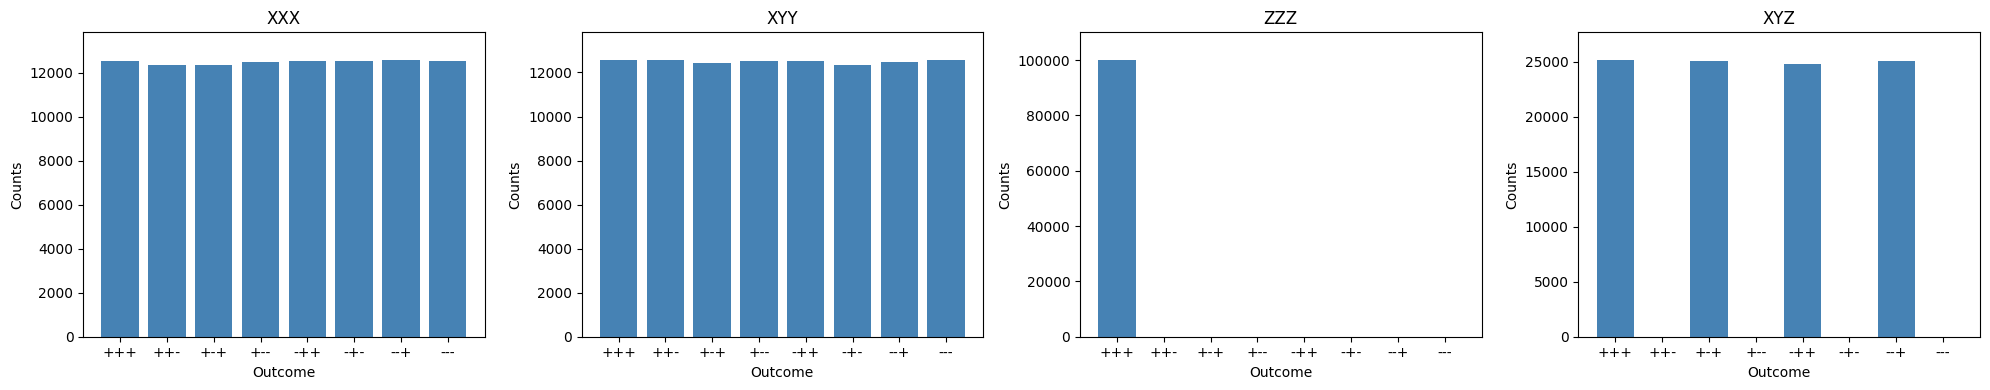

In [7]:
rho_000_cp = cp.zeros((8, 8), dtype=cp.complex128)
rho_000_cp[0, 0] = 1

N = 100_000

result_cp = pauli_measurement(rho_000_cp, N)

print(result_cp)
plot_counts(
    result_cp,
    ["XXX", "XYY", "ZZZ", "XYZ"]
)

100000


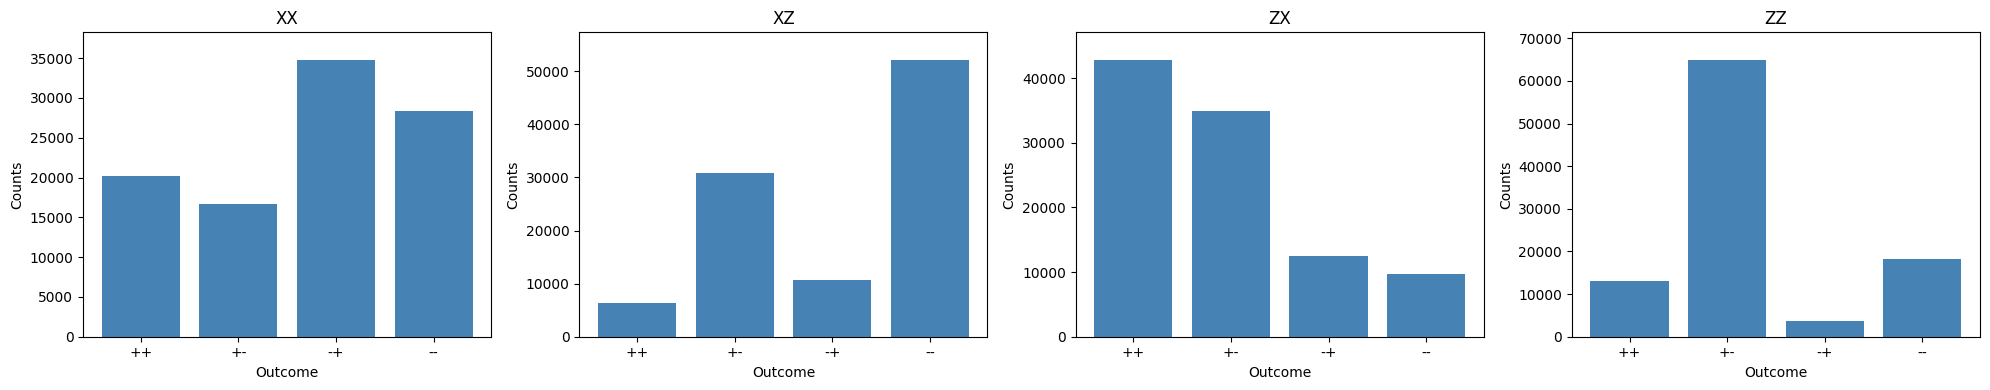

In [7]:
rho = get_random_product(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

100000


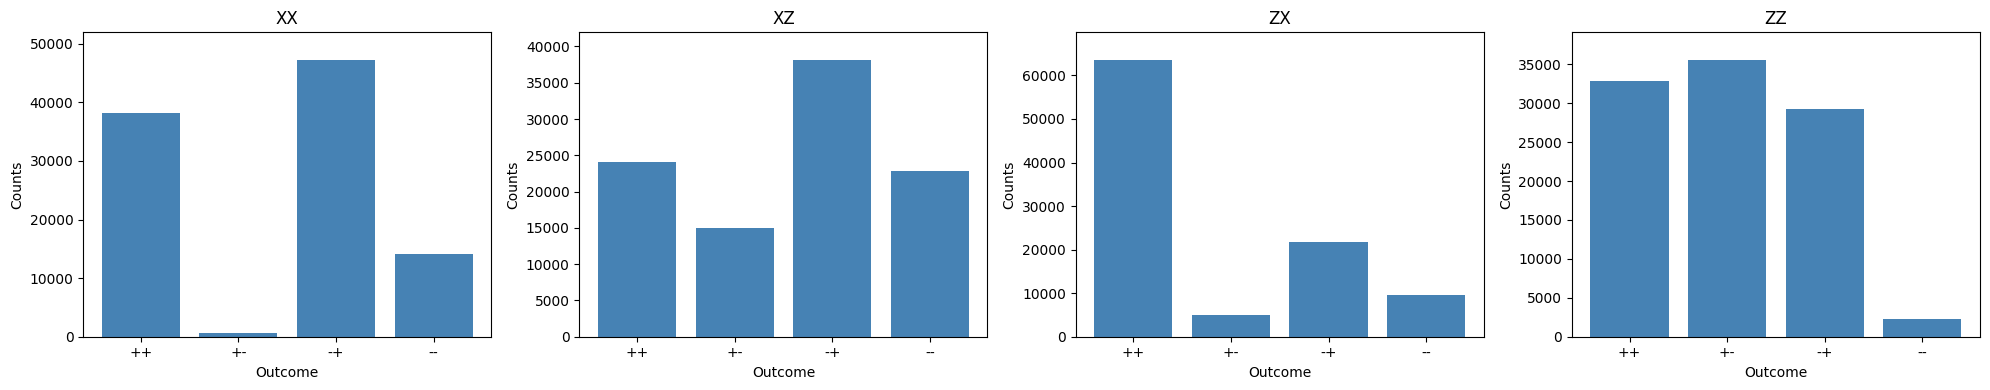

In [9]:
rho = get_random_haar(2, array_api_compat.numpy, np.random)

N = 100_000

result = pauli_measurement(rho, N)

print(result.N)

plot_counts(result, ["XX", "XZ", "ZX", "ZZ"])

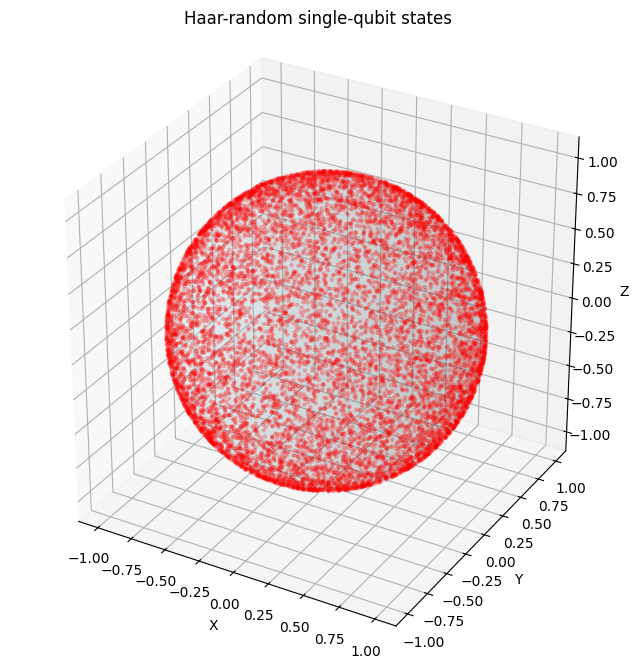

In [15]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_haar(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Haar-random single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

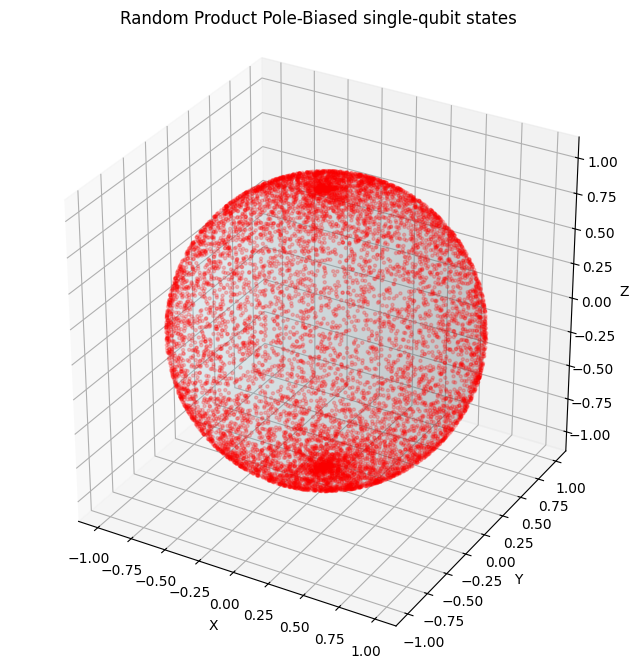

In [16]:
bloch_vectors = []
num_samples = 10000

for _ in range(num_samples):
    rho = get_random_product_pole_biased(1, array_api_compat.numpy, np.random)
    r = bloch_vector(rho)
    bloch_vectors.append(r)

rng = np.random.default_rng(42)

vectors_np = np.asarray(bloch_vectors)

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection="3d")

# Bloch sphere
u = np.linspace(0, 2 * np.pi, 100)
v = np.linspace(0, np.pi, 50)

x_sphere = np.outer(np.cos(u), np.sin(v))
y_sphere = np.outer(np.sin(u), np.sin(v))
z_sphere = np.outer(np.ones_like(u), np.cos(v))

ax.plot_surface(
    x_sphere,
    y_sphere,
    z_sphere,
    color="lightblue",
    alpha=0.15,
    linewidth=0
)

# Haar-random states
ax.scatter(
    vectors_np[:, 0],
    vectors_np[:, 1],
    vectors_np[:, 2],
    s=5,
    alpha=0.2,
    color="red"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_title("Random Product Pole-Biased single-qubit states")

ax.set_box_aspect([1, 1, 1])

plt.show()

In [16]:
xp = np

zero = xp.asarray([1, 0], dtype=xp.complex128)
plus = xp.asarray([1, 1], dtype=xp.complex128) / xp.sqrt(2)

psi = xp.kron(zero, plus)
rho = xp.outer(psi, xp.conj(psi))

result = pauli_measurement(rho, 100_000)

for measurement in ["ZX", "XZ"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

ZX [100000      0      0      0]
XZ [25017 24829 25013 25141]


XY [100000      0      0      0]
YX [25060 24934 24847 25159]


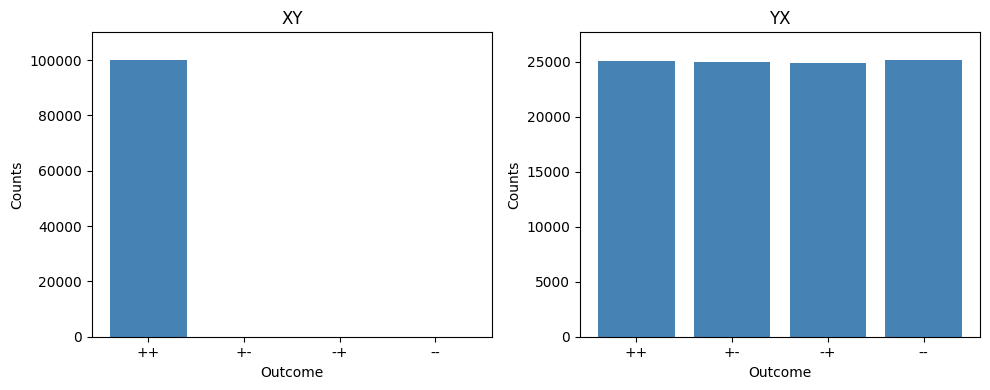

In [19]:
zero = xp.asarray([1, 0], dtype=xp.complex128)
one  = xp.asarray([0, 1], dtype=xp.complex128)

plus_x = (zero + one) / xp.sqrt(2)
plus_y = (zero + 1j * one) / xp.sqrt(2)

psi = xp.kron(plus_x, plus_y)
rho = xp.outer(psi, xp.conj(psi))

for measurement in ["XY", "YX"]:
    i = result.measurements.index(measurement)
    print(measurement, result.counts[i])

plot_counts(result, ["XY", "YX"])

# Hardware Benchmarking

### CPU (NumPy)

### GPU (CuPy)

# Noise Resilience

### Data generation

In [53]:
n = 4
Ns = list(2**i for i in range(3, 20))

# xp = cp
xp = np

haar_rho = get_random_haar(n, xp)
# X = xp.asarray([
#     [0, 1],
#     [1, 0]
# ], dtype=xp.complex128)
# haar_rho = (xp.identity(2**n) + xp.kron(X, X)) / 2**n
prod_rho = get_random_product(n, xp)

haar_countss = []
prod_countss = []
for N in Ns:
    haar_counts = pauli_measurement(haar_rho, N).counts
    prod_counts = pauli_measurement(prod_rho, N).counts
    haar_countss.append(haar_counts)
    prod_countss.append(prod_counts)

### Estimation

In [54]:
haar_fs = []
prod_fs = []
haar_ns = []
prod_ns = []
for i, N in enumerate(Ns):
    haar_counts = haar_countss[i]
    prod_counts = prod_countss[i]

    haar_est = inverse_estimator(haar_counts)
    prod_est = inverse_estimator(prod_counts)

    haar_f = float(xp.linalg.norm(haar_rho - haar_est))
    prod_f = float(xp.linalg.norm(prod_rho - prod_est))
    # haar_f = fidelity(haar_rho, haar_est)
    # prod_f = fidelity(prod_rho, prod_est)
    haar_fs.append(haar_f)
    prod_fs.append(prod_f)

    haar_n = float(negativity(haar_est))
    prod_n = float(negativity(prod_est))
    haar_ns.append(haar_n)
    prod_ns.append(prod_n)

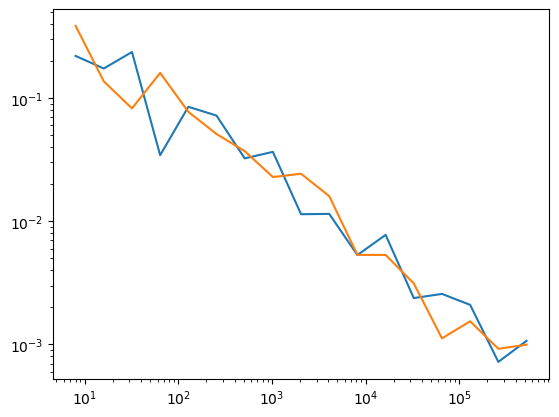

In [40]:
plt.plot(Ns, haar_ns)
plt.plot(Ns, prod_ns)

plt.xscale('log')
plt.yscale('log')

# Advanced Protocols (Classical Shadows)